### Import libraries

In [2]:
%matplotlib inline
import os
import sys
import csv
import torch
import pathlib
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.cm as cm

### Import Autoencoder class

In [4]:
folder_path = str(pathlib.Path().resolve().parents[1])
data_path = 'D:\HPC-VTA_autoencoder_data'
plot_folder_path = folder_path + '/Plots/Experiment1'
print("Folder path =", folder_path)
sys.path.append(folder_path + '/Notebooks/AE_class/')
from Conv_AE_weebots_downsampled import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\HPC-VTA_Autoencoder


### Check libraries versions

In [6]:
print(f"torch version: {torch.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sb.__version__}")

torch version: 2.2.1+cu121
numpy version: 1.26.4
matplotlib version: 3.8.0
seaborn version: 0.12.2


### Check GPU

In [8]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
#print(torch.cuda.current_device())
#print(torch.cuda.device(0))
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


### Hyperparameters

In [10]:
control = False
save_plots = True
normalize_ratemaps = True

In [11]:
#Model
n_hidden = 200
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

#Others
total_experiments = 20
experiment_n = 1 #Start = 1
trial_t = 0

actv_threshold = 0.05

if control == True:
    envs = ['Tmaze_old1', 'Tmaze_old2', 'Tmaze_old3']
else:
    envs = ['Tmaze_0', 'Tmaze_1', 'Tmaze_2']

print(envs)

['Tmaze_0', 'Tmaze_1', 'Tmaze_2']


### Import ratemaps

In [13]:
def update_experiment_ratemaps(exp_n, data_path, control=False):
    if control==True:
        CACHE_DIR = data_path + "/Models/Control/Control-Exp" + str(exp_n) + "_cache_ratemaps"
    else:
        CACHE_DIR = data_path + "/Models/Experimental/Exp" + str(exp_n) + "_cache_ratemaps"

    print('CACHE_DIR =' , CACHE_DIR)
    
    cache_path = os.path.join(CACHE_DIR, f"ratemaps.npy")
    
    arr = np.load(cache_path, mmap_mode="r")  # no full load into RAM
    return arr, CACHE_DIR

arr, CACHE_DIR = update_experiment_ratemaps(experiment_n, data_path, control=control)

CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp1_cache_ratemaps


In [14]:
#Normalize ratemaps
def ratemap_normalizer(arr):
    normal_arr = []
    
    for mt in range(len(arr)):
        mt_arr = []
        for unit in range(n_hidden):
            ratemap = arr[mt][unit]
            if np.max(ratemap) != 0.0:
                mt_arr.append(ratemap / np.max(ratemap))
            else:
                mt_arr.append(ratemap)
    
        normal_arr.append(mt_arr)
    
    arr = np.array(normal_arr)

    return arr

if normalize_ratemaps == True:
    arr = ratemap_normalizer(arr)

In [15]:
def load_loss_history(CACHE_DIR):
    loss_csv_filename = CACHE_DIR + '/loss_history.csv'
    
    history_loss = []
    with open(loss_csv_filename, mode='r', newline='') as file:
        reader = csv.DictReader(file)
        for row in reader:
            value = row.get('Image_loss')
            history_loss.append(float(value))
    return history_loss

history_loss = load_loss_history(CACHE_DIR)

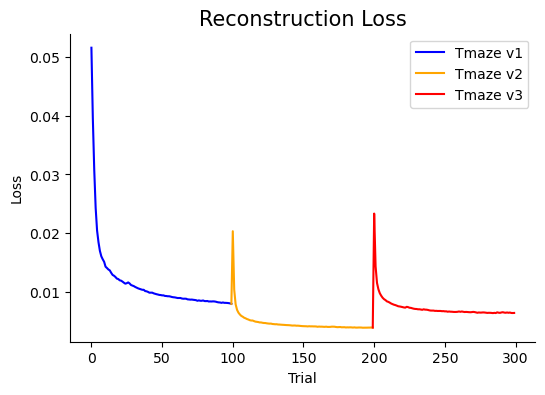

In [16]:
def plot_loss_history(history_loss):
    fig = plt.figure(figsize=(6,4))
    plt.plot(range(0, 100), history_loss[:100], color='blue', label='Tmaze v1')
    plt.plot(range(99, 200), history_loss[99:200], color='orange', label='Tmaze v2')
    plt.plot(range(199, 300), history_loss[199:], color='red', label='Tmaze v3')
    
    plt.xlabel('Trial')
    plt.ylabel('Loss')
    sb.despine()
    plt.legend()
    plt.title('Reconstruction Loss', fontsize=15)
    plt.show()

plot_loss_history(history_loss)

### Explore ratemaps at environment m and trial t

In [18]:
trial_idx = 300
trial_ratemaps = arr[trial_idx]
trial_ratemaps.shape

(200, 50, 50)

In [19]:
plot_ratemaps(trial_ratemaps[:100], 'plot_folder_path', save=False)

In [20]:
peak_activity = []
for i in range(n_hidden):
    peak_activity.append(np.max(arr[trial_idx][i]))

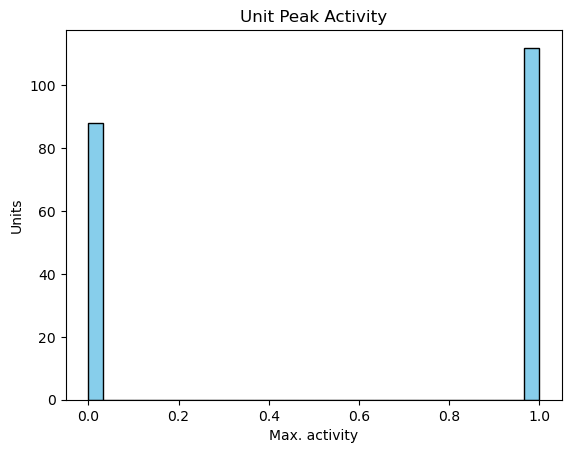

Silent units = 88.0


In [21]:
hist = plt.hist(peak_activity, bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Max. activity')
plt.ylabel('Units')
plt.title('Unit Peak Activity')

# Display the plot
plt.show()

print('Silent units =', hist[0][0])

## Metrics Functions

In [23]:
def get_num_active_units(ratemaps, actv_threshold):
    active_units = 0
    for i in range(len(ratemaps)):
        peak = np.max(ratemaps[i])
        if peak > actv_threshold:
            active_units += 1
    return active_units
#####################################################################    

def get_max_coverage(ratemaps, actv_threshold):
    #TDefine maximal firing coverage once, at the first trial of the first environment
    max_size = 0
    
    for i in range(len(ratemaps)):
        size = np.sum(ratemaps[i] > actv_threshold)
        if size > max_size:
            max_size = size

    return max_size
#####################################################################

def get_mean_unit_coverage_at_t(ratemaps, max_coverage, actv_threshold):
    #Normalize the activation coverage of each unit.
    unit_coverage = []
    
    for i in range(len(ratemaps)):
        unit_coverage.append(np.sum(ratemaps[i] > actv_threshold) / max_coverage)

    # Define mean unit coverage of (only) active units
    mean_unit_coverage = np.mean([x for x in unit_coverage if x != 0.0])
    
    return mean_unit_coverage
#####################################################################

def representative_unit_sums(ratemaps):
    #Take 4 reference points for measuring summed activity at representative locations
    top_left_unit_sum = np.sum(ratemaps[:, 40, 10])
    top_center_unit_sum = np.sum(ratemaps[:, 40, 25])
    top_right_unit_sum = np.sum(ratemaps[:, 40, 40])
    bottom_center_unit_sum = np.sum(ratemaps[:, 10, 25])
    return top_left_unit_sum, top_center_unit_sum, top_right_unit_sum, bottom_center_unit_sum
#####################################################################

def representative_unit_count(ratemaps, actv_threshold):
    #Take 4 reference points for measuring the number of active units at representative locations
    top_left_unit_count = np.sum(ratemaps[:, 40, 10] > actv_threshold)
    top_center_unit_count = np.sum(ratemaps[:, 40, 25] > actv_threshold)
    top_right_unit_count = np.sum(ratemaps[:, 40, 40] > actv_threshold)
    bottom_center_unit_count = np.sum(ratemaps[:, 10, 25] > actv_threshold)
    return top_left_unit_count, top_center_unit_count, top_right_unit_count, bottom_center_unit_count
#####################################################################

def compute_mean_std(data):
    arr = np.array(data)        # shape (15, 301)
    mean = arr.mean(axis=0)     # shape (301,)
    std  = arr.std(axis=0)      # shape (301,)
    return mean, std

## Plotting functions

In [25]:
def hide_ticks(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

#####################################################################################################

def add_colorbar(ax, im):
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction & pad for size and spacing
    cbar.ax.tick_params(labelsize=8)  # Adjust tick label size

#####################################################################################################

def plot_loss_history(mean, std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    segments = [
        (range(0, num_epochs), mean[0:num_epochs], std[0:num_epochs], 'blue', 'Tmaze v1'),
        (range(num_epochs-1, (num_epochs*2)),  mean[num_epochs-1:(num_epochs*2)], std[num_epochs-1:(num_epochs*2)], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)-1, (num_epochs*3)), mean[(num_epochs*2)-1:], std[(num_epochs*2)-1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    sb.despine()
    plt.legend()
    plt.title('Mean Reconstruction Loss', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/History_loss.png', format='png')
        
#####################################################################################################

def plot_loss_history_by_experiment(all_history_loss, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig, ax = plt.subplots(figsize=figsize)
    
    mean, std = compute_mean_std(all_history_loss)
    timesteps = np.arange(300)
    colors = cm.tab20.colors 
    
    # Individual series
    for i, series in enumerate(all_history_loss):
        ax.plot(timesteps, series, color=colors[i], linewidth=0.8, alpha=0.8)
    
    # Mean and std envelope
    ax.plot(timesteps, mean, color="green", linewidth=1.5, label="Mean", zorder=5)
    ax.fill_between(timesteps, mean - std, mean + std,
                    alpha=0.25, color="green", label="±1 std")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("Mean Reconstruction Loss by Experiment", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    sb.despine()
    plt.tight_layout()
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/History_loss_by_exp.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/History_loss_by_exp.png', format='png')

#####################################################################################################

def plot_unit_coverage(mean, std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    segments = [
        (range(1, num_epochs+2), mean[1:num_epochs+2], std[1:num_epochs+2], 'blue', 'Tmaze v1'),
        (range(num_epochs+1, (num_epochs*2)+2),  mean[num_epochs+1:(num_epochs*2)+2], std[num_epochs+1:(num_epochs*2)+2], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)+1, (num_epochs*3)+1), mean[(num_epochs*2)+1:], std[(num_epochs*2)+1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.scatter(range(0, 1), mean[:1], color='black', label='Pre', s=25)

    plt.xlabel('Epoch')
    plt.ylabel('Coverage (%)')
    sb.despine()
    plt.legend()
    plt.title('Mean Unit Coverage', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Unit_coverage.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Unit_coverage.png', format='png')

#####################################################################################################

def plot_unit_coverage_by_experiment(all_mean_unit_coverage, figsize=(6, 4), save_plots=False, plot_folder_path=''):
    fig, ax = plt.subplots(figsize=figsize)
    
    mean, std = compute_mean_std(all_mean_unit_coverage)
    timesteps = np.arange(301)
    colors = cm.tab20.colors 
    
    # Individual series
    for i, series in enumerate(all_mean_unit_coverage):
        ax.plot(timesteps, series, color=colors[i], linewidth=0.8, alpha=0.8)
    
    # Mean and std envelope
    ax.plot(timesteps, mean, color="green", linewidth=1.5, label="Mean", zorder=5)
    ax.fill_between(timesteps, mean - std, mean + std,
                    alpha=0.25, color="green", label="±1 std")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Coverage %", fontsize=12)
    ax.set_title("Mean Unit Coverage by Experiment", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    sb.despine()
    plt.tight_layout()
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Unit_coverage_by_exp.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Unit_coverage_by_exp.png', format='png')

#####################################################################################################

def plot_active_units_count(mean, std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    segments = [
        (range(1, num_epochs+2), mean[1:num_epochs+2], std[1:num_epochs+2], 'blue', 'Tmaze v1'),
        (range(num_epochs+1, (num_epochs*2)+2),  mean[num_epochs+1:(num_epochs*2)+2], std[num_epochs+1:(num_epochs*2)+2], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)+1, (num_epochs*3)+1), mean[(num_epochs*2)+1:], std[(num_epochs*2)+1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.scatter(range(0, 1), mean[:1], color='black', label='Pre', s=25)

    plt.xlabel('Epoch')
    plt.ylabel('Units (out of 200)')
    sb.despine()
    plt.legend()
    plt.title('Active units count', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Active_units.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Active_units.png', format='png')

#####################################################################################################

def plot_active_units_count_by_experiment(all_num_active_units, figsize=(6, 4), save_plots=False, plot_folder_path=''):
    fig, ax = plt.subplots(figsize=figsize)
    
    mean, std = compute_mean_std(all_num_active_units)
    timesteps = np.arange(301)
    colors = cm.tab20.colors 
    
    # Individual series
    for i, series in enumerate(all_num_active_units):
        ax.plot(timesteps, series, color=colors[i], linewidth=0.8, alpha=0.8)
    
    # Mean and std envelope
    ax.plot(timesteps, mean, color="green", linewidth=1.5, label="Mean", zorder=5)
    ax.fill_between(timesteps, mean - std, mean + std,
                    alpha=0.25, color="green", label="±1 std")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Units (out of 200)", fontsize=12)
    ax.set_title("Mean Number of Active Units by Experiment", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    sb.despine()
    plt.tight_layout()
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Active_units_by_exp.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Active_units_by_exp.png', format='png')

#####################################################################################################

def plot_activity_rep_loc(all_BC_rep_unit_sum_history, all_TL_rep_unit_sum_history, all_TC_rep_unit_sum_history, all_TR_rep_unit_sum_history, figsize=(6,4), save_plots=False, plot_folder_path=''):
    BC_mean, BC_std = compute_mean_std(all_BC_rep_unit_sum_history)
    TL_mean, TL_std = compute_mean_std(all_TL_rep_unit_sum_history)
    TC_mean, TC_std = compute_mean_std(all_TC_rep_unit_sum_history)
    TR_mean, TR_std = compute_mean_std(all_TR_rep_unit_sum_history)

    timesteps = np.arange(len(all_BC_rep_unit_sum_history[0]))
    
    
    fig = plt.figure(figsize=figsize)

    plt.plot(BC_mean[1:], label='Bottom-Center', color='#1f77b4')
    plt.fill_between(timesteps, BC_mean - BC_std, BC_mean + BC_std, alpha=0.25, color="#1f77b4")
    plt.plot(TL_mean[1:], label='Top-Left', color='#ff7f0e')
    plt.fill_between(timesteps, TL_mean - TL_std, TL_mean + TL_std, alpha=0.25, color="#ff7f0e")
    plt.plot(TC_mean[1:], label='Top-Center', color='#2ca02c')
    plt.fill_between(timesteps, TC_mean - TC_std, TC_mean + TC_std, alpha=0.25, color="#2ca02c")
    plt.plot(TR_mean[1:], label='Top-Right', color='#d62728')
    plt.fill_between(timesteps, TR_mean - TR_std, TR_mean + TR_std, alpha=0.25, color="#d62728", label="±1 std")
    plt.scatter(range(0, 1), BC_mean[:1], color='#1f77b4', s=15)
    plt.scatter(range(0, 1), TL_mean[:1], color='#ff7f0e', s=15)
    plt.scatter(range(0, 1), TC_mean[:1], color='#2ca02c', s=15)
    plt.scatter(range(0, 1), TR_mean[:1], color='#d62728', s=15)
    
    
    plt.xlabel('Epoch')
    plt.ylabel('Sum activity')
    sb.despine()
    plt.title('Sum actv. at representative locations', fontsize=15)
    plt.legend()
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Sum_actv_rep_locations.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Sum_actv_rep_locations.png', format='png')
        
#####################################################################################################

def plot_units_rep_loc(all_BC_rep_unit_count_history, all_TL_rep_unit_count_history, all_TC_rep_unit_count_history, all_TR_rep_unit_count_history, figsize=(6,4), save_plots=False, plot_folder_path=''):
    BC_mean, BC_std = compute_mean_std(all_BC_rep_unit_count_history)
    TL_mean, TL_std = compute_mean_std(all_TL_rep_unit_count_history)
    TC_mean, TC_std = compute_mean_std(all_TC_rep_unit_count_history)
    TR_mean, TR_std = compute_mean_std(all_TR_rep_unit_count_history)

    timesteps = np.arange(len(all_BC_rep_unit_count_history[0]))
    fig = plt.figure(figsize=figsize)

    plt.plot(BC_mean[1:], label='Bottom-Center', color='#1f77b4')
    plt.fill_between(timesteps, BC_mean - BC_std, BC_mean + BC_std, alpha=0.25, color="#1f77b4")
    plt.plot(TL_mean[1:], label='Top-Left', color='#ff7f0e')
    plt.fill_between(timesteps, TL_mean - TL_std, TL_mean + TL_std, alpha=0.25, color="#ff7f0e")
    plt.plot(TC_mean[1:], label='Top-Center', color='#2ca02c')
    plt.fill_between(timesteps, TC_mean - TC_std, TC_mean + TC_std, alpha=0.25, color="#2ca02c")
    plt.plot(TR_mean[1:], label='Top-Right', color='#d62728')
    plt.fill_between(timesteps, TR_mean - TR_std, TR_mean + TR_std, alpha=0.25, color="#d62728", label="±1 std")
    plt.scatter(range(0, 1), BC_mean[:1], color='#1f77b4', s=15)
    plt.scatter(range(0, 1), TL_mean[:1], color='#ff7f0e', s=15)
    plt.scatter(range(0, 1), TC_mean[:1], color='#2ca02c', s=15)
    plt.scatter(range(0, 1), TR_mean[:1], color='#d62728', s=15)
    
    
    plt.xlabel('Epoch')
    plt.ylabel('Freq.')
    sb.despine()
    plt.title('Active units at representative locations', fontsize=15)
    plt.legend()
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Sum_units_rep_locations.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Sum_units_rep_locations.png', format='png')
        
#####################################################################################################

def plot_cogmap_correlation(mean, std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    segments = [
        (range(1, num_epochs), mean[1:num_epochs], std[1:num_epochs], 'blue', 'Tmaze v1'),
        (range(num_epochs-1, (num_epochs*2)),  mean[num_epochs-1:(num_epochs*2)], std[num_epochs-1:(num_epochs*2)], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)-1, (num_epochs*3)), mean[(num_epochs*2)-1:], std[(num_epochs*2)-1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.scatter(range(0, 1), mean[:1], color='black', label='Pre', s=25)

    plt.xlabel('Epoch')
    plt.ylabel('Pearson Correlation')
    sb.despine()
    plt.legend(loc=4)
    plt.title('Cog. Maps Similarity (t vs. t–1)', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Map_similarity.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Map_similarity.png', format='png')

#####################################################################################################

def plot_cogmap_correlation_by_experiment(all_correlation_history, figsize=(6, 4), save_plots=False, plot_folder_path=''):
    fig, ax = plt.subplots(figsize=figsize)
    
    mean, std = compute_mean_std(all_correlation_history)
    timesteps = np.arange(300)
    colors = cm.tab20.colors 
    
    # Individual series
    for i, series in enumerate(all_correlation_history):
        ax.plot(timesteps, series, color=colors[i], linewidth=0.8, alpha=0.8)
    
    # Mean and std envelope
    ax.plot(timesteps, mean, color="green", linewidth=1.5, label="Mean", zorder=5)
    ax.fill_between(timesteps, mean - std, mean + std,
                    alpha=0.25, color="green", label="±1 std")
    
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Pearson Correlation", fontsize=12)
    ax.set_title('Cog. Maps Similarity by Experiments(t vs. t–1)', fontsize=14, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.7)
    ax.grid(True, linestyle="--", alpha=0.3)
    
    sb.despine()
    plt.tight_layout()
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Map_similarity_by_experiment.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Map_similarity_by_experiment.png', format='png')

#####################################################################################################

def plot_img_reconstruction(input_img, mt0, mt50, mt100, figsize=(14,3), m0_bool=False, save_plots=False, plot_folder_path=''):

    fig = plt.figure(figsize=figsize)
    plt.subplot(141)
    plt.imshow(input_img)
    plt.suptitle('Image reconstruction', fontsize=15)
    plt.title('Input', fontsize=10)
    plt.ylabel('Tmaze v3')
    
    plt.subplot(142)
    plt.imshow(predict(input_img, mt0))
    if m0_bool == True:
        plt.title('Trial 0', fontsize=10)
    else:
        plt.title('Trial 1', fontsize=10)

    plt.subplot(143)
    plt.imshow(predict(input_img, mt50))
    plt.title('Trial 50', fontsize=10)

    plt.subplot(144)
    plt.imshow(predict(input_img, mt100))
    plt.title('Trial 100', fontsize=10)

    plt.show()
    
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Tmaze3_img_recon.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Tmaze3_img_recon.png', format='png')

#####################################################################################################

def plot_example_ratemaps_progress(example_units, example_ratemaps, figsize=(15, 8), save_plots=False, plot_folder_path=''):
    
    fig, axes = plt.subplots(5, 9, figsize=figsize)
    colors = ['blue'] * 3 + ['orange'] * 3 + ['red'] * 3
    ts = ['0', '10', '100', '1', '10', '100', '1', '10', '100']

    for i, ax in enumerate(axes.flatten()):
        # Determine the column index (0–8)
        col = i % 9
        color = colors[col]
    
        # Draw dashed T-maze using the color for this column
        ax.axhline(y=35, xmin=0, xmax=0.3, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=35, xmin=0.7, xmax=1, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=49, xmin=0, xmax=1, color=color, linestyle='--', linewidth=2)
        ax.axhline(y=0, xmin=0.3, xmax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=35, ymin=0, ymax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=15, ymin=0, ymax=0.7, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=0, ymin=0.7, ymax=1, color=color, linestyle='--', linewidth=2)
        ax.axvline(x=49, ymin=0.7, ymax=1, color=color, linestyle='--', linewidth=2)
    
    for mt in range(len(example_ratemaps)):
        for unit in range(len(example_ratemaps[mt])):
            im = axes[unit, mt].imshow(example_ratemaps[mt][unit], cmap='hot', origin='lower')
            hide_ticks(axes[unit, mt])
            if mt == 0: axes[unit, mt].set_ylabel("Unit " + str(example_units[unit]), fontsize=15, labelpad=10)
            if unit == 0: axes[unit, mt].set_title('T' + ts[mt], fontsize=15)

    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/example_units.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/example_units.png', format='png')

## Model update functions

In [27]:
def format_dataset(env):
    data_path = folder_path + '/Datasets/' + env
    csv_filename = data_path + "/data.csv"

    img_filename_list = os.listdir(data_path)
    num_images = len(img_filename_list) -1 

    return data_path, csv_filename, num_images

#####################################################################

def Load_env_dataset(env_idx):
    # Load dataset every T-maze version
    env = envs[env_idx] #Choose environment index
    data_path, csv_filename, num_images = format_dataset(env)

    print("Dataset Path =", data_path)
    print("Num. Images in Dataset =", num_images)
    
    dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)

    return dataset, csv_filename

## Data processing loop

In [29]:
RO_all_history_loss = []
RO_all_num_active_units = []
RO_all_mean_unit_coverage_history = []
RO_all_correlation_history = []

RO_all_TL_rep_unit_sum_history = []
RO_all_TC_rep_unit_sum_history = []
RO_all_TR_rep_unit_sum_history = []
RO_all_BC_rep_unit_sum_history = []

RO_all_TL_rep_unit_count_history = []
RO_all_TC_rep_unit_count_history = []
RO_all_TR_rep_unit_count_history = []
RO_all_BC_rep_unit_count_history = []


for i in range(total_experiments):
    
    arr, CACHE_DIR = update_experiment_ratemaps(experiment_n + i, data_path, control=control)
    history_loss = load_loss_history(CACHE_DIR)

    if normalize_ratemaps == True:
        print('Normalizing ratemaps for experiment', str(experiment_n + i))
        arr = ratemap_normalizer(arr)
    else:
        print('Importing ratemaps from experiment', str(experiment_n + i))

    num_active_units = []
    mean_unit_coverage_history = []
    correlation_history = []
    
    TL_rep_unit_sum_history = []
    TC_rep_unit_sum_history = []
    TR_rep_unit_sum_history = []
    BC_rep_unit_sum_history = []
    
    TL_rep_unit_count_history = []
    TC_rep_unit_count_history = []
    TR_rep_unit_count_history = []
    BC_rep_unit_count_history = []

    for t in range(arr.shape[0]):
        if t == 0:
            max_coverage = get_max_coverage(arr[t], actv_threshold)
        
        num_active_units.append(get_num_active_units(arr[t], actv_threshold))
        mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(arr[t], max_coverage, actv_threshold))
    
        # Unit activity at representative locations
        TL_sum, TC_sum, TR_sum, BC_sum = representative_unit_sums(arr[t])
        TL_rep_unit_sum_history.append(TL_sum)
        TC_rep_unit_sum_history.append(TC_sum)
        TR_rep_unit_sum_history.append(TR_sum)
        BC_rep_unit_sum_history.append(BC_sum)
        
        TL_count, TC_count, TR_count, BC_count = representative_unit_count(arr[t], actv_threshold)
        TL_rep_unit_count_history.append(TL_count)
        TC_rep_unit_count_history.append(TC_count)
        TR_rep_unit_count_history.append(TR_count)
        BC_rep_unit_count_history.append(BC_count)
    
        # Measure map correlation
        if t != 0:
            flat_t0 = prev_ratemaps.flatten()
            flat_t1 = arr[t].flatten()
            corr = np.corrcoef(flat_t0, flat_t1)[0, 1]
            correlation_history.append(corr)
    
        prev_ratemaps = arr[t]

    RO_all_history_loss.append(history_loss)
    RO_all_num_active_units.append(num_active_units)
    RO_all_mean_unit_coverage_history.append(mean_unit_coverage_history)
    RO_all_correlation_history.append(correlation_history)
    RO_all_TL_rep_unit_sum_history.append(TL_rep_unit_sum_history)
    RO_all_TC_rep_unit_sum_history.append(TC_rep_unit_sum_history)
    RO_all_TR_rep_unit_sum_history.append(TR_rep_unit_sum_history)
    RO_all_BC_rep_unit_sum_history.append(BC_rep_unit_sum_history)
    RO_all_TL_rep_unit_count_history.append(TL_rep_unit_count_history)
    RO_all_TC_rep_unit_count_history.append(TC_rep_unit_count_history)
    RO_all_TR_rep_unit_count_history.append(TR_rep_unit_count_history)
    RO_all_BC_rep_unit_count_history.append(BC_rep_unit_count_history)

CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp1_cache_ratemaps
Normalizing ratemaps for experiment 1
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp2_cache_ratemaps
Normalizing ratemaps for experiment 2
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp3_cache_ratemaps
Normalizing ratemaps for experiment 3
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp4_cache_ratemaps
Normalizing ratemaps for experiment 4
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp5_cache_ratemaps
Normalizing ratemaps for experiment 5
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp6_cache_ratemaps
Normalizing ratemaps for experiment 6
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp7_cache_ratemaps
Normalizing ratemaps for experiment 7
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimental/Exp8_cache_ratemaps
Normalizing ratemaps for experiment 8
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Experimen

In [30]:
RO_all_mean_unit_coverage = []
for i in range(total_experiments):
    RO_all_mean_unit_coverage.append([x * 100 for x in RO_all_mean_unit_coverage_history[i]])

In [31]:
len(RO_all_history_loss[0])

300

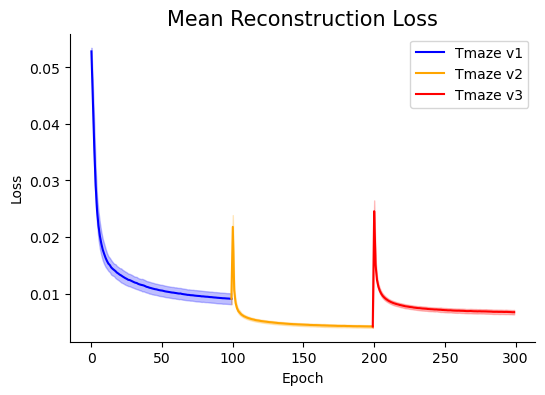

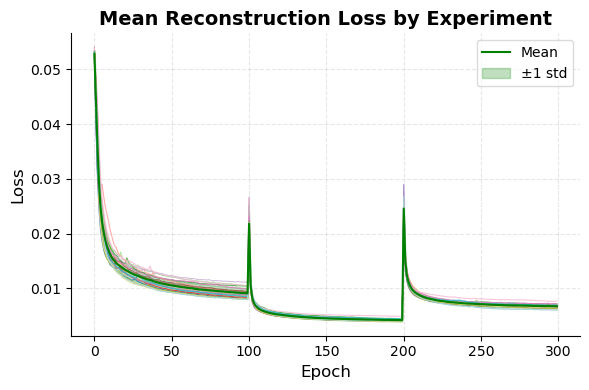

In [32]:
RO_loss_mean, RO_loss_std = compute_mean_std(RO_all_history_loss)
plot_loss_history(RO_loss_mean, RO_loss_std, save_plots=save_plots, plot_folder_path=plot_folder_path)
plot_loss_history_by_experiment(RO_all_history_loss, save_plots=save_plots, plot_folder_path=plot_folder_path)

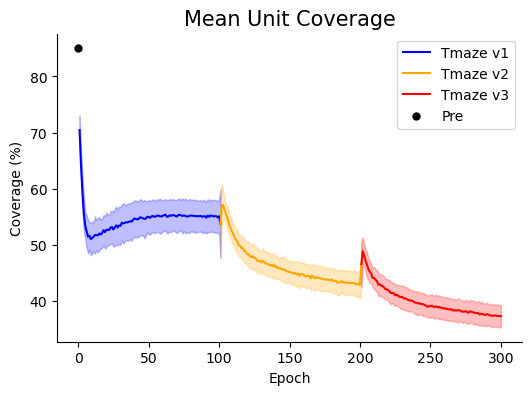

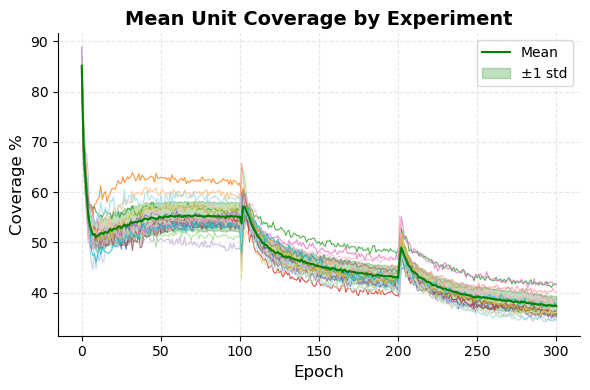

In [33]:
RO_coverage_mean, RO_coverage_std = compute_mean_std(RO_all_mean_unit_coverage)
plot_unit_coverage(RO_coverage_mean, RO_coverage_std, save_plots=save_plots, plot_folder_path=plot_folder_path)
plot_unit_coverage_by_experiment(RO_all_mean_unit_coverage, save_plots=save_plots, plot_folder_path=plot_folder_path)

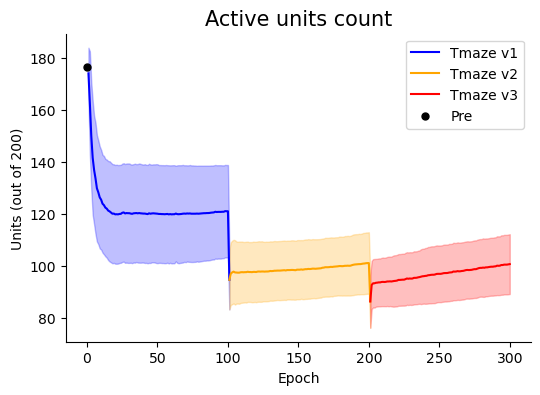

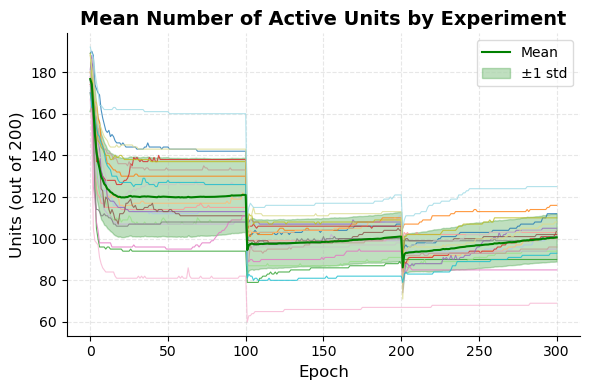

In [34]:
RO_active_units_mean, RO_active_units_std = compute_mean_std(RO_all_num_active_units)
plot_active_units_count(RO_active_units_mean, RO_active_units_std, save_plots=save_plots, plot_folder_path=plot_folder_path)
plot_active_units_count_by_experiment(RO_all_num_active_units, save_plots=save_plots, plot_folder_path=plot_folder_path)

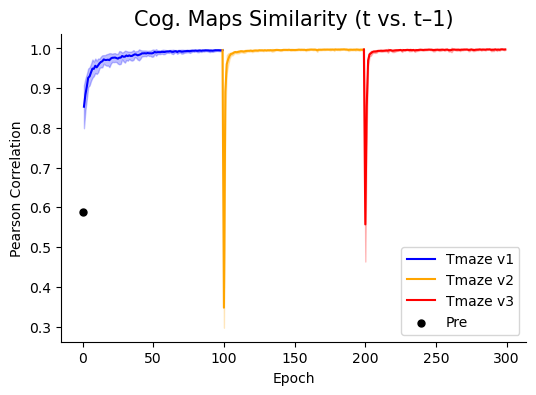

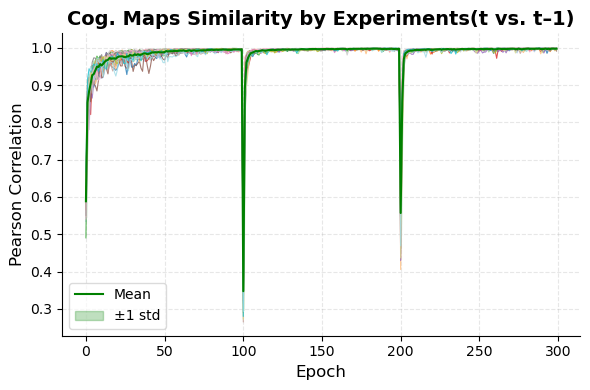

In [35]:
RO_map_correlation_mean, RO_map_correlation_std = compute_mean_std(RO_all_correlation_history)
plot_cogmap_correlation(RO_map_correlation_mean, RO_map_correlation_std, save_plots=save_plots, plot_folder_path=plot_folder_path)
plot_cogmap_correlation_by_experiment(RO_all_correlation_history, save_plots=save_plots, plot_folder_path=plot_folder_path)

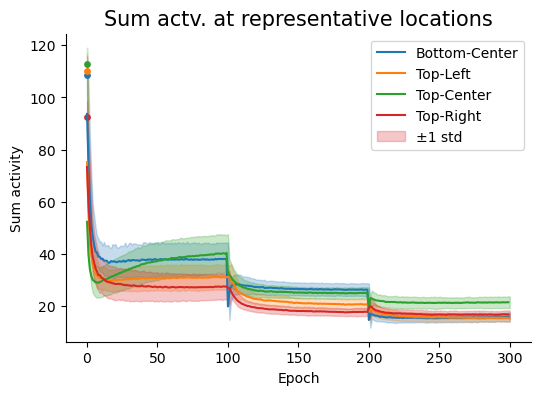

In [36]:
plot_activity_rep_loc(RO_all_BC_rep_unit_sum_history, RO_all_TL_rep_unit_sum_history, RO_all_TC_rep_unit_sum_history, RO_all_TR_rep_unit_sum_history,  save_plots=save_plots, plot_folder_path=plot_folder_path)

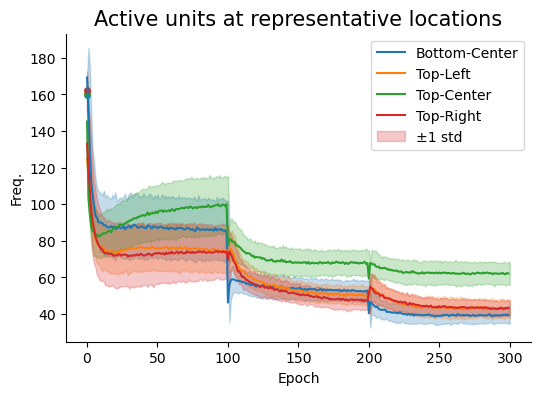

In [37]:
plot_units_rep_loc(RO_all_BC_rep_unit_count_history, RO_all_TL_rep_unit_count_history, RO_all_TC_rep_unit_count_history, RO_all_TR_rep_unit_count_history, save_plots=save_plots, plot_folder_path=plot_folder_path)

In [38]:
control = True
total_experiments = 20
envs = ['Tmaze_old1', 'Tmaze_old2', 'Tmaze_old3']

In [40]:
control_all_history_loss = []
control_all_num_active_units = []
control_all_mean_unit_coverage_history = []
control_all_correlation_history = []

control_all_TL_rep_unit_sum_history = []
control_all_TC_rep_unit_sum_history = []
control_all_TR_rep_unit_sum_history = []
control_all_BC_rep_unit_sum_history = []

control_all_TL_rep_unit_count_history = []
control_all_TC_rep_unit_count_history = []
control_all_TR_rep_unit_count_history = []
control_all_BC_rep_unit_count_history = []


for i in range(total_experiments):
    
    arr, CACHE_DIR = update_experiment_ratemaps(experiment_n + i, data_path, control=control)
    history_loss = load_loss_history(CACHE_DIR)

    if normalize_ratemaps == True:
        print('Normalizing ratemaps for experiment', str(experiment_n + i))
        arr = ratemap_normalizer(arr)
    else:
        print('Importing ratemaps from experiment', str(experiment_n + i))

    num_active_units = []
    mean_unit_coverage_history = []
    correlation_history = []
    
    TL_rep_unit_sum_history = []
    TC_rep_unit_sum_history = []
    TR_rep_unit_sum_history = []
    BC_rep_unit_sum_history = []
    
    TL_rep_unit_count_history = []
    TC_rep_unit_count_history = []
    TR_rep_unit_count_history = []
    BC_rep_unit_count_history = []

    for t in range(arr.shape[0]):
        if t == 0:
            max_coverage = get_max_coverage(arr[t], actv_threshold)
        
        num_active_units.append(get_num_active_units(arr[t], actv_threshold))
        mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(arr[t], max_coverage, actv_threshold))
    
        # Unit activity at representative locations
        TL_sum, TC_sum, TR_sum, BC_sum = representative_unit_sums(arr[t])
        TL_rep_unit_sum_history.append(TL_sum)
        TC_rep_unit_sum_history.append(TC_sum)
        TR_rep_unit_sum_history.append(TR_sum)
        BC_rep_unit_sum_history.append(BC_sum)
        
        TL_count, TC_count, TR_count, BC_count = representative_unit_count(arr[t], actv_threshold)
        TL_rep_unit_count_history.append(TL_count)
        TC_rep_unit_count_history.append(TC_count)
        TR_rep_unit_count_history.append(TR_count)
        BC_rep_unit_count_history.append(BC_count)
    
        # Measure map correlation
        if t != 0:
            flat_t0 = prev_ratemaps.flatten()
            flat_t1 = arr[t].flatten()
            corr = np.corrcoef(flat_t0, flat_t1)[0, 1]
            correlation_history.append(corr)
    
        prev_ratemaps = arr[t]

    control_all_history_loss.append(history_loss)
    control_all_num_active_units.append(num_active_units)
    control_all_mean_unit_coverage_history.append(mean_unit_coverage_history)
    control_all_correlation_history.append(correlation_history)
    control_all_TL_rep_unit_sum_history.append(TL_rep_unit_sum_history)
    control_all_TC_rep_unit_sum_history.append(TC_rep_unit_sum_history)
    control_all_TR_rep_unit_sum_history.append(TR_rep_unit_sum_history)
    control_all_BC_rep_unit_sum_history.append(BC_rep_unit_sum_history)
    control_all_TL_rep_unit_count_history.append(TL_rep_unit_count_history)
    control_all_TC_rep_unit_count_history.append(TC_rep_unit_count_history)
    control_all_TR_rep_unit_count_history.append(TR_rep_unit_count_history)
    control_all_BC_rep_unit_count_history.append(BC_rep_unit_count_history)

CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Control/Control-Exp1_cache_ratemaps
Normalizing ratemaps for experiment 1
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Control/Control-Exp2_cache_ratemaps
Normalizing ratemaps for experiment 2
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Control/Control-Exp3_cache_ratemaps
Normalizing ratemaps for experiment 3
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Control/Control-Exp4_cache_ratemaps
Normalizing ratemaps for experiment 4
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Control/Control-Exp5_cache_ratemaps
Normalizing ratemaps for experiment 5
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Control/Control-Exp6_cache_ratemaps
Normalizing ratemaps for experiment 6
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Control/Control-Exp7_cache_ratemaps
Normalizing ratemaps for experiment 7
CACHE_DIR = D:\HPC-VTA_autoencoder_data/Models/Control/Control-Exp8_cache_ratemaps
Normalizing ratemaps for experiment 8
CACHE_DIR = D:\HPC-VTA_autoencod

In [41]:
control_all_mean_unit_coverage = []
for i in range(total_experiments):
    control_all_mean_unit_coverage.append([x * 100 for x in control_all_mean_unit_coverage_history[i]])

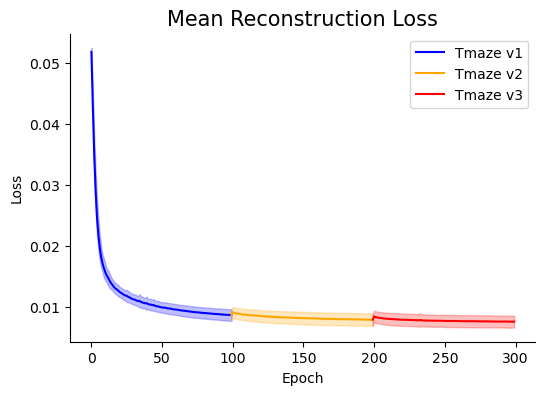

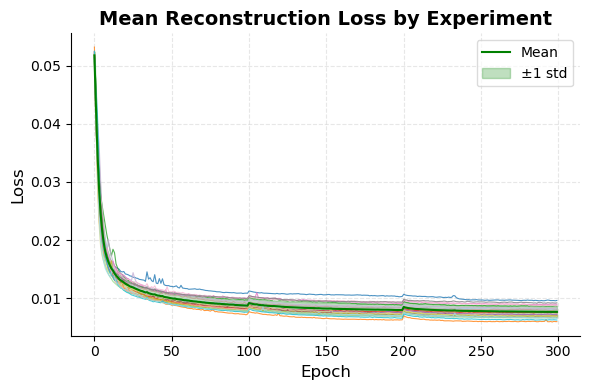

In [42]:
control_loss_mean, control_loss_std = compute_mean_std(control_all_history_loss)
plot_loss_history(control_loss_mean, control_loss_std, save_plots=save_plots, plot_folder_path=plot_folder_path)
plot_loss_history_by_experiment(control_all_history_loss, save_plots=save_plots, plot_folder_path=plot_folder_path)

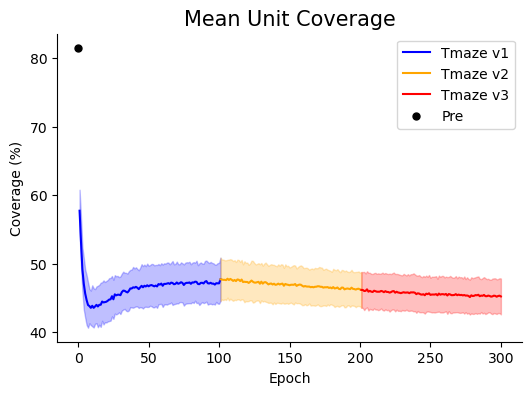

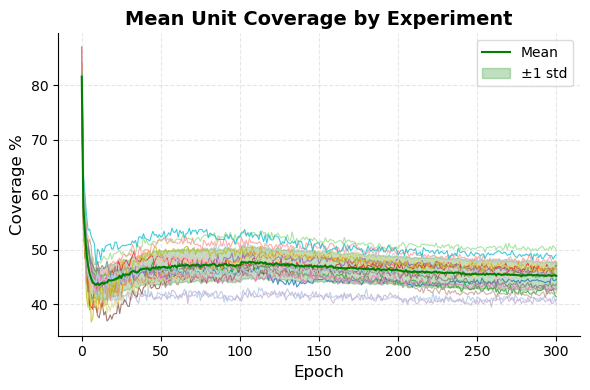

In [43]:
control_coverage_mean, control_coverage_std = compute_mean_std(control_all_mean_unit_coverage)
plot_unit_coverage(control_coverage_mean, control_coverage_std, save_plots=save_plots, plot_folder_path=plot_folder_path)
plot_unit_coverage_by_experiment(control_all_mean_unit_coverage, save_plots=save_plots, plot_folder_path=plot_folder_path)

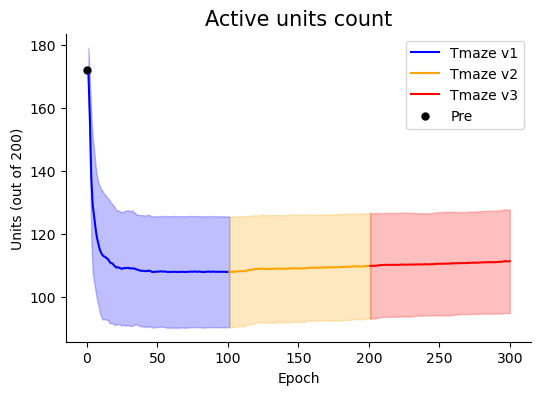

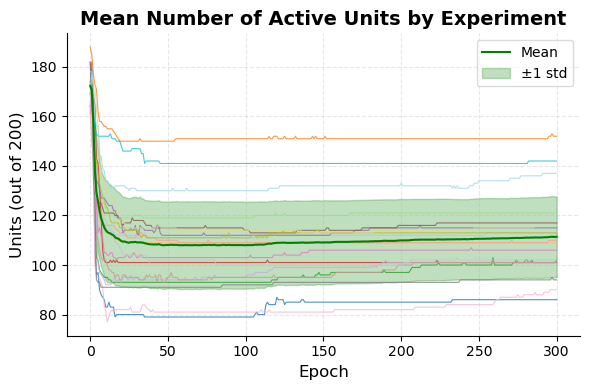

In [44]:
control_active_units_mean, control_active_units_std = compute_mean_std(control_all_num_active_units)
plot_active_units_count(control_active_units_mean, control_active_units_std, save_plots=save_plots, plot_folder_path=plot_folder_path)
plot_active_units_count_by_experiment(control_all_num_active_units, save_plots=save_plots, plot_folder_path=plot_folder_path)

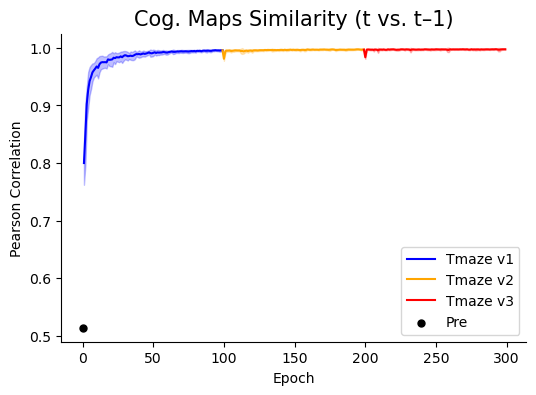

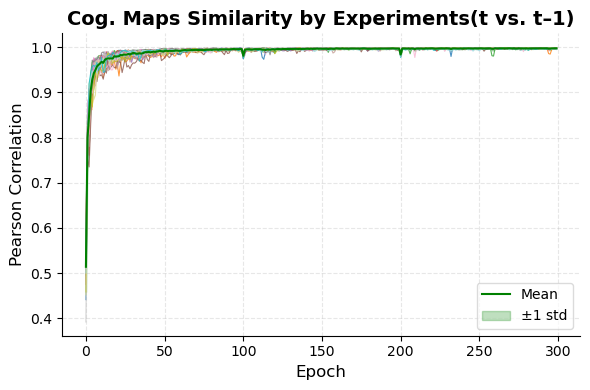

In [45]:
control_map_correlation_mean, control_map_correlation_std = compute_mean_std(control_all_correlation_history)
plot_cogmap_correlation(control_map_correlation_mean, control_map_correlation_std, save_plots=save_plots, plot_folder_path=plot_folder_path)
plot_cogmap_correlation_by_experiment(control_all_correlation_history, save_plots=save_plots, plot_folder_path=plot_folder_path)

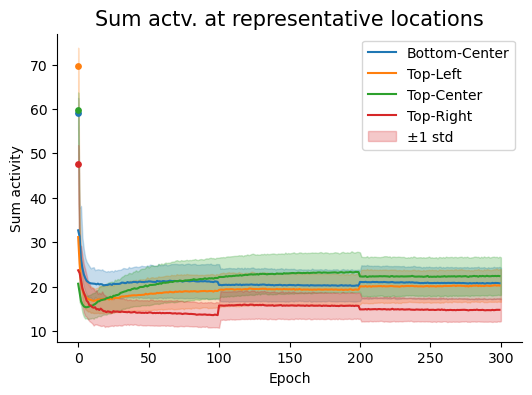

In [46]:
plot_activity_rep_loc(control_all_BC_rep_unit_sum_history, control_all_TL_rep_unit_sum_history, control_all_TC_rep_unit_sum_history, control_all_TR_rep_unit_sum_history,  save_plots=save_plots, plot_folder_path=plot_folder_path)

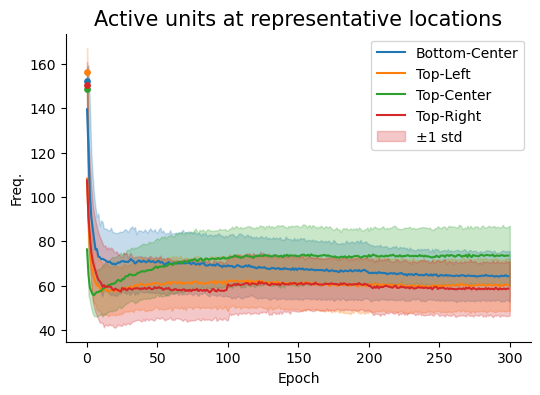

In [47]:
plot_units_rep_loc(control_all_BC_rep_unit_count_history, control_all_TL_rep_unit_count_history, control_all_TC_rep_unit_count_history, control_all_TR_rep_unit_count_history, save_plots=save_plots, plot_folder_path=plot_folder_path)

In [57]:
def plot_loss_history(RO_mean, control_mean, RO_std, control_std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    plt.plot(control_mean, color='gray', label='Control', alpha=0.25)
    control_x = range(0, num_epochs*3)
    plt.fill_between(control_x, control_mean - control_std, control_mean + control_std, alpha=0.10, color='gray')
    
    segments = [
        (range(0, num_epochs), RO_mean[0:num_epochs], RO_std[0:num_epochs], 'blue', 'Tmaze v1'),
        (range(num_epochs-1, (num_epochs*2)),  RO_mean[num_epochs-1:(num_epochs*2)], RO_std[num_epochs-1:(num_epochs*2)], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)-1, (num_epochs*3)), RO_mean[(num_epochs*2)-1:], RO_std[(num_epochs*2)-1:], 'red', 'Tmaze v3'),
    ]

    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    sb.despine()
    plt.legend()
    plt.title('Mean Reconstruction Loss', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/History_loss.png', format='png')

#####################################################################################################

def plot_unit_coverage(RO_mean, control_mean, RO_std, control_std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    #plt.scatter(range(0, 1), control_mean[:1], color='gray', label='Pre-Control', s=25)
    plt.plot(control_mean[1:], color='gray', label='Control', alpha=0.25)
    control_x = range(1, (num_epochs*3)+1)
    plt.fill_between(control_x, control_mean[1:] - control_std[1:], control_mean[1:] + control_std[1:], alpha=0.10, color='gray')
        
    segments = [
        (range(1, num_epochs+2), RO_mean[1:num_epochs+2], RO_std[1:num_epochs+2], 'blue', 'Tmaze v1'),
        (range(num_epochs+1, (num_epochs*2)+2),  RO_mean[num_epochs+1:(num_epochs*2)+2], RO_std[num_epochs+1:(num_epochs*2)+2], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)+1, (num_epochs*3)+1), RO_mean[(num_epochs*2)+1:], RO_std[(num_epochs*2)+1:], 'red', 'Tmaze v3'),
    ]

    #plt.scatter(range(0, 1), RO_mean[:1], color='black', label='Pre', s=25)
    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    

    plt.xlabel('Epoch')
    plt.ylabel('Coverage (%)')
    sb.despine()
    plt.legend()
    plt.title('Mean Unit Coverage', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Unit_coverage.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Unit_coverage.png', format='png')

#####################################################################################################

def plot_active_units_count(RO_mean, control_mean, RO_std, control_std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    #plt.scatter(range(0, 1), control_mean[:1], color='gray', label='Pre-Control', s=25)
    plt.plot(control_mean[1:], color='gray', label='Control', alpha=0.25)
    control_x = range(1, (num_epochs*3)+1)
    plt.fill_between(control_x, control_mean[1:] - control_std[1:], control_mean[1:] + control_std[1:], alpha=0.10, color='gray')

    segments = [
        (range(1, num_epochs+2), RO_mean[1:num_epochs+2], RO_std[1:num_epochs+2], 'blue', 'Tmaze v1'),
        (range(num_epochs+1, (num_epochs*2)+2),  RO_mean[num_epochs+1:(num_epochs*2)+2], RO_std[num_epochs+1:(num_epochs*2)+2], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)+1, (num_epochs*3)+1), RO_mean[(num_epochs*2)+1:], RO_std[(num_epochs*2)+1:], 'red', 'Tmaze v3'),
    ]

    #plt.scatter(range(0, 1), RO_mean[:1], color='black', label='Pre', s=25)
    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    

    plt.xlabel('Epoch')
    plt.ylabel('Units (out of 200)')
    sb.despine()
    plt.legend()
    plt.title('Active units count', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Active_units.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Active_units.png', format='png')

#####################################################################################################

def plot_cogmap_correlation(RO_mean, control_mean, RO_std, control_std, figsize=(6,4), save_plots=False, plot_folder_path=''):
    fig = plt.figure(figsize=figsize)

    

    segments = [
        (range(1, num_epochs), RO_mean[1:num_epochs], RO_std[1:num_epochs], 'blue', 'Tmaze v1'),
        (range(num_epochs-1, (num_epochs*2)),  RO_mean[num_epochs-1:(num_epochs*2)], RO_std[num_epochs-1:(num_epochs*2)], 'orange', 'Tmaze v2'),
        (range((num_epochs*2)-1, (num_epochs*3)), RO_mean[(num_epochs*2)-1:], RO_std[(num_epochs*2)-1:], 'red', 'Tmaze v3'),
    ]

    #plt.scatter(range(0, 1), RO_mean[:1], color='black', label='Pre', s=25)
    for x, m, s, color, label in segments:
        x = list(x)
        plt.plot(x, m, color=color, label=label)
        plt.fill_between(x, m - s, m + s, alpha=0.25, color=color)

    #plt.scatter(range(0, 1), control_mean[:1], color='gray', label='Pre-Control', s=25)
    plt.plot(control_mean[1:], color='gray', label='Control', alpha=0.5)
    control_x = range(1, (num_epochs*3))
    plt.fill_between(control_x, control_mean[1:] - control_std[1:], control_mean[1:] + control_std[1:], alpha=0.10, color='gray')

    plt.xlabel('Epoch')
    plt.ylabel('Pearson Correlation')
    sb.despine()
    plt.legend(loc=4)
    plt.title('Cog. Maps Similarity (t vs. t–1)', fontsize=15)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_folder_path + '/Map_similarity.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_folder_path + '/Map_similarity.png', format='png')

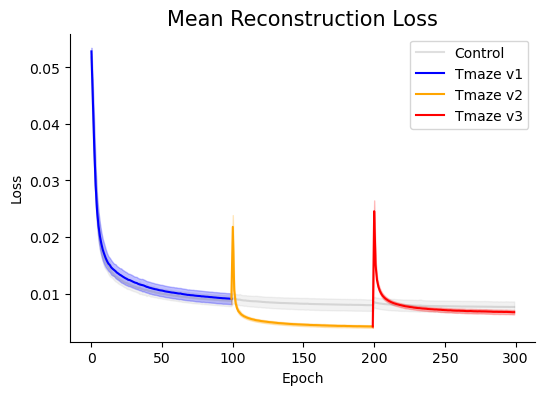

In [59]:
plot_loss_history(RO_loss_mean, control_loss_mean, RO_loss_std, control_loss_std, figsize=(6,4), save_plots=save_plots, plot_folder_path=plot_folder_path)

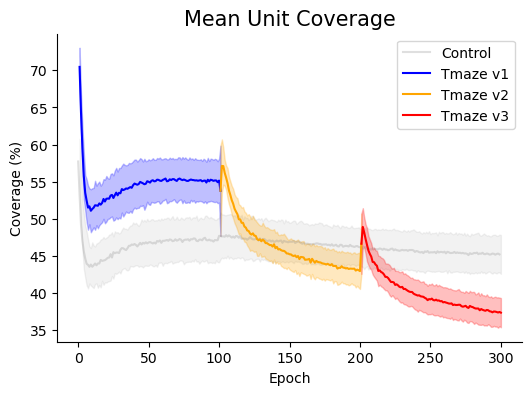

In [61]:
plot_unit_coverage(RO_coverage_mean, control_coverage_mean, RO_coverage_std, control_coverage_std, save_plots=save_plots, plot_folder_path=plot_folder_path)

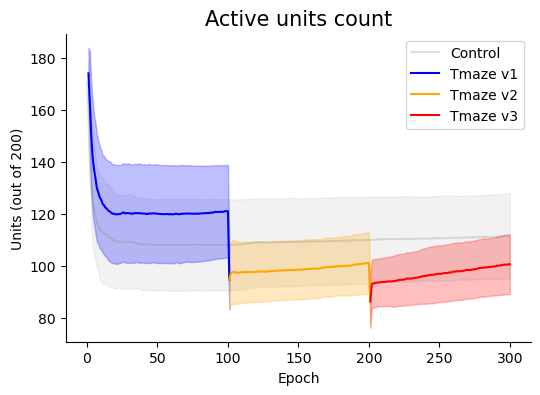

In [63]:
plot_active_units_count(RO_active_units_mean, control_active_units_mean, RO_active_units_std, control_active_units_std, save_plots=save_plots, plot_folder_path=plot_folder_path)

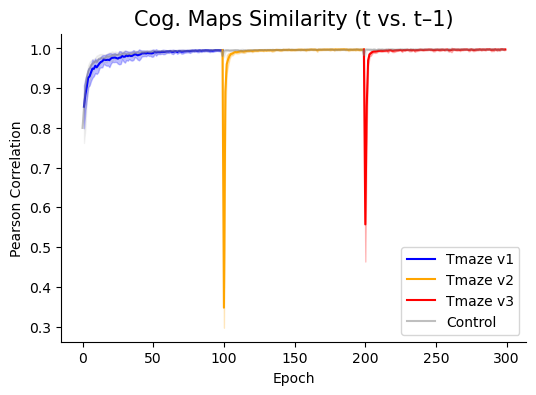

In [65]:
plot_cogmap_correlation(RO_map_correlation_mean, control_map_correlation_mean, RO_map_correlation_std, control_map_correlation_std, save_plots=save_plots, plot_folder_path=plot_folder_path)